# Import Packages

In [1]:

import numpy as np
import os
from sklearn.metrics import confusion_matrix
import seaborn as sn; sn.set(font_scale=1.4)
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tqdm import tqdm

In [2]:
class_names = ['Normal','Osteoarthritis']
class_names_label = {class_name:i for i, class_name in enumerate(class_names)}

nb_classes = len(class_names)

IMAGE_SIZE = (150, 150)

# Loading the Data
We have to write a load_data function that load the images and the labels from the folder.

In [3]:
def load_data():

    datasets = [r'C:\Users\Pavan Kumar\Music\knee bone- kamala\train', r'C:\Users\Pavan Kumar\Music\knee bone- kamala\test']

    output = []

    # Iterate through training and test sets
    for dataset in datasets:

        images = []
        labels = []

        print("Loading {}".format(dataset))

        # Iterate through each folder corresponding to a category
        for folder in os.listdir(dataset):
            label = class_names_label[folder]

            # Iterate through each image in our folder
            for file in tqdm(os.listdir(os.path.join(dataset, folder))):

                # Get the path name of the image
                img_path = os.path.join(os.path.join(dataset, folder), file)

                # Open and resize the img
                image = cv2.imread(img_path)
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image = cv2.resize(image, IMAGE_SIZE)

                # Append the image and its corresponding label to the output
                images.append(image)
                labels.append(label)

        images = np.array(images, dtype = 'float32')
        labels = np.array(labels, dtype = 'int32')

        output.append((images, labels))

    return output

In [4]:
(train_images, train_labels), (test_images, test_labels) = load_data()

Loading C:\Users\Pavan Kumar\Music\knee bone- kamala\train


100%|█████████████████████████████████████████████████████████████████████████████| 1540/1540 [00:06<00:00, 249.25it/s]


Loading C:\Users\Pavan Kumar\Music\knee bone- kamala\test


100%|███████████████████████████████████████████████████████████████████████████████| 276/276 [00:01<00:00, 209.34it/s]


In [5]:
train_images, train_labels = shuffle(train_images, train_labels, random_state=25)

In [6]:
n_train = train_labels.shape[0]
n_test = test_labels.shape[0]

print ("Number of training examples: {}".format(n_train))
print ("Number of testing examples: {}".format(n_test))
print ("Each image is of size: {}".format(IMAGE_SIZE))

Number of training examples: 2350
Number of testing examples: 845
Each image is of size: (150, 150)


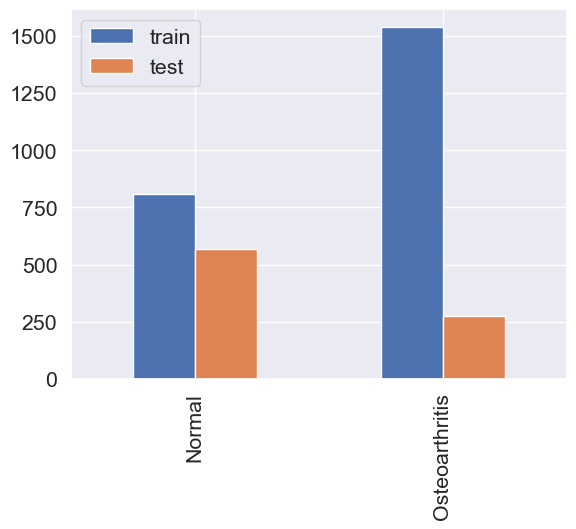

In [7]:
import pandas as pd

_, train_counts = np.unique(train_labels, return_counts=True)
_, test_counts = np.unique(test_labels, return_counts=True)
pd.DataFrame({'train': train_counts,
                    'test': test_counts},
             index=class_names
            ).plot.bar()
plt.show()

## Good practice: scale the data

In [8]:
train_images = train_images / 255.0
test_images = test_images / 255.0

## Visualize the data
We can display a random image from the training set.

In [9]:
import matplotlib.pyplot as plt

def display_examples(class_names, images, labels):
    """
    Display 25 images from the images array with its corresponding labels
    """
    fig = plt.figure(figsize=(10,10))
    fig.suptitle("Some examples of images of the dataset", fontsize=16)
    for i in range(25):
        plt.subplot(5,5,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i], cmap=plt.cm.binary)
        plt.xlabel(class_names[labels[i]])
    plt.show()


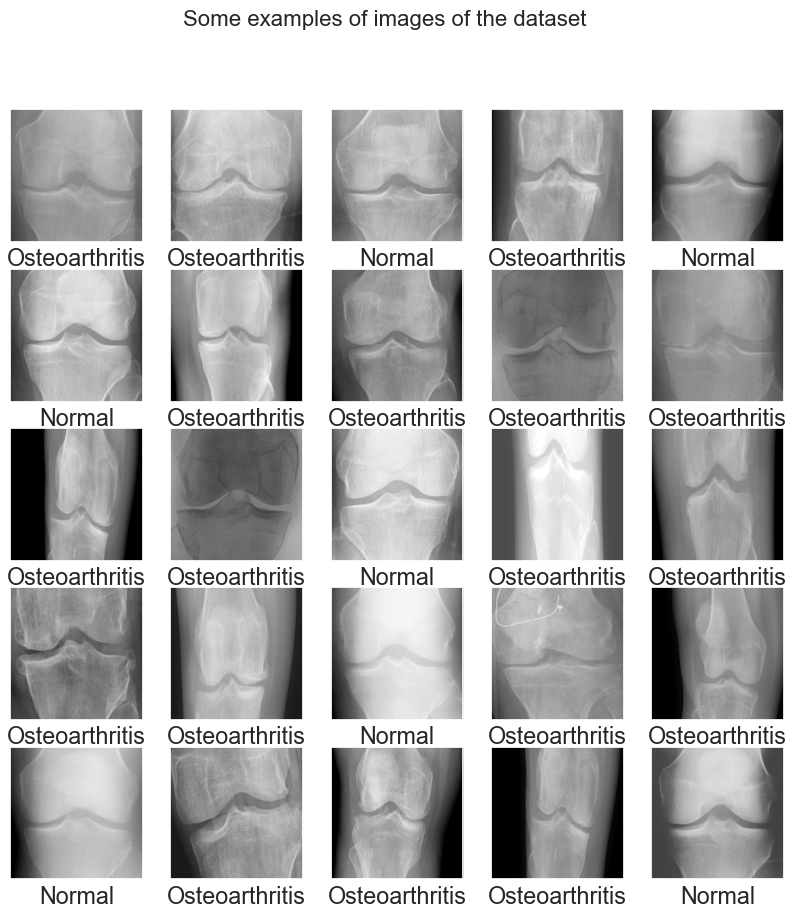

In [10]:
display_examples(class_names, train_images, train_labels)

# CNN

In [11]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation = 'relu', input_shape = (150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(32, (3, 3), activation = 'relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

D:\Anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])

In [13]:
history = model.fit(train_images, train_labels, batch_size=128, epochs=40, validation_split = 0.2)

Epoch 1/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.4851 - loss: 1.4542 - val_accuracy: 0.5277 - val_loss: 0.7146
Epoch 2/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 15s 993ms/step - accuracy: 0.6137 - loss: 0.6199 - val_accuracy: 0.6191 - val_loss: 0.6207
Epoch 3/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.6565 - loss: 0.5572 - val_accuracy: 0.6213 - val_loss: 0.5924
Epoch 4/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 951ms/step - accuracy: 0.6868 - loss: 0.5342 - val_accuracy: 0.6191 - val_loss: 0.6014
Epoch 5/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 957ms/step - accuracy: 0.6859 - loss: 0.5252 - val_accuracy: 0.7149 - val_loss: 0.5598
Epoch 6/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 15s 962ms/step - accuracy: 0.7045 - loss: 0.5161 - val_accuracy: 0.7404 - val_loss: 0.5386
Epoch 7/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 954ms/step - accuracy: 0.7217 - loss: 0.4963 - val_accuracy: 0.7745 - val_loss: 0.5134
Epoch 8/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 15s 956ms/step - accuracy: 0.7420 - loss: 0.4912 - val_accuracy: 

In [14]:
test_loss = model.evaluate(test_images, test_labels)

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.2340 - loss: 10.1404


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step
[1]


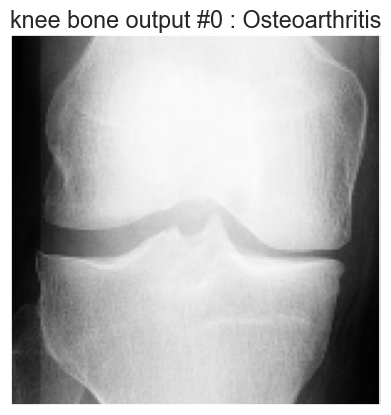

In [15]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing import image
test_image = image.load_img(r'C:\Users\Pavan Kumar\Music\knee bone- kamala\test\Osteoarthritis\9094693_1.png', target_size = (150, 150))
test_image = image.img_to_array(test_image)
test_image = np.expand_dims(test_image, axis = 0)
predictions = model.predict(test_image)     # Vector of probabilities
pred_labels = np.argmax(predictions, axis = 1) # We take the highest probability
print(pred_labels )
index = np.random.randint(test_image.shape[0])
plt.figure()
plt.imshow(test_image[index].astype('uint8'))
plt.xticks([])
plt.yticks([])
plt.grid(False)
plt.title('knee bone output #{} : '.format(index) + class_names[pred_labels[index]])
plt.show()